# Notebook For Figure Sup 05 Run between tower in group 2 mice

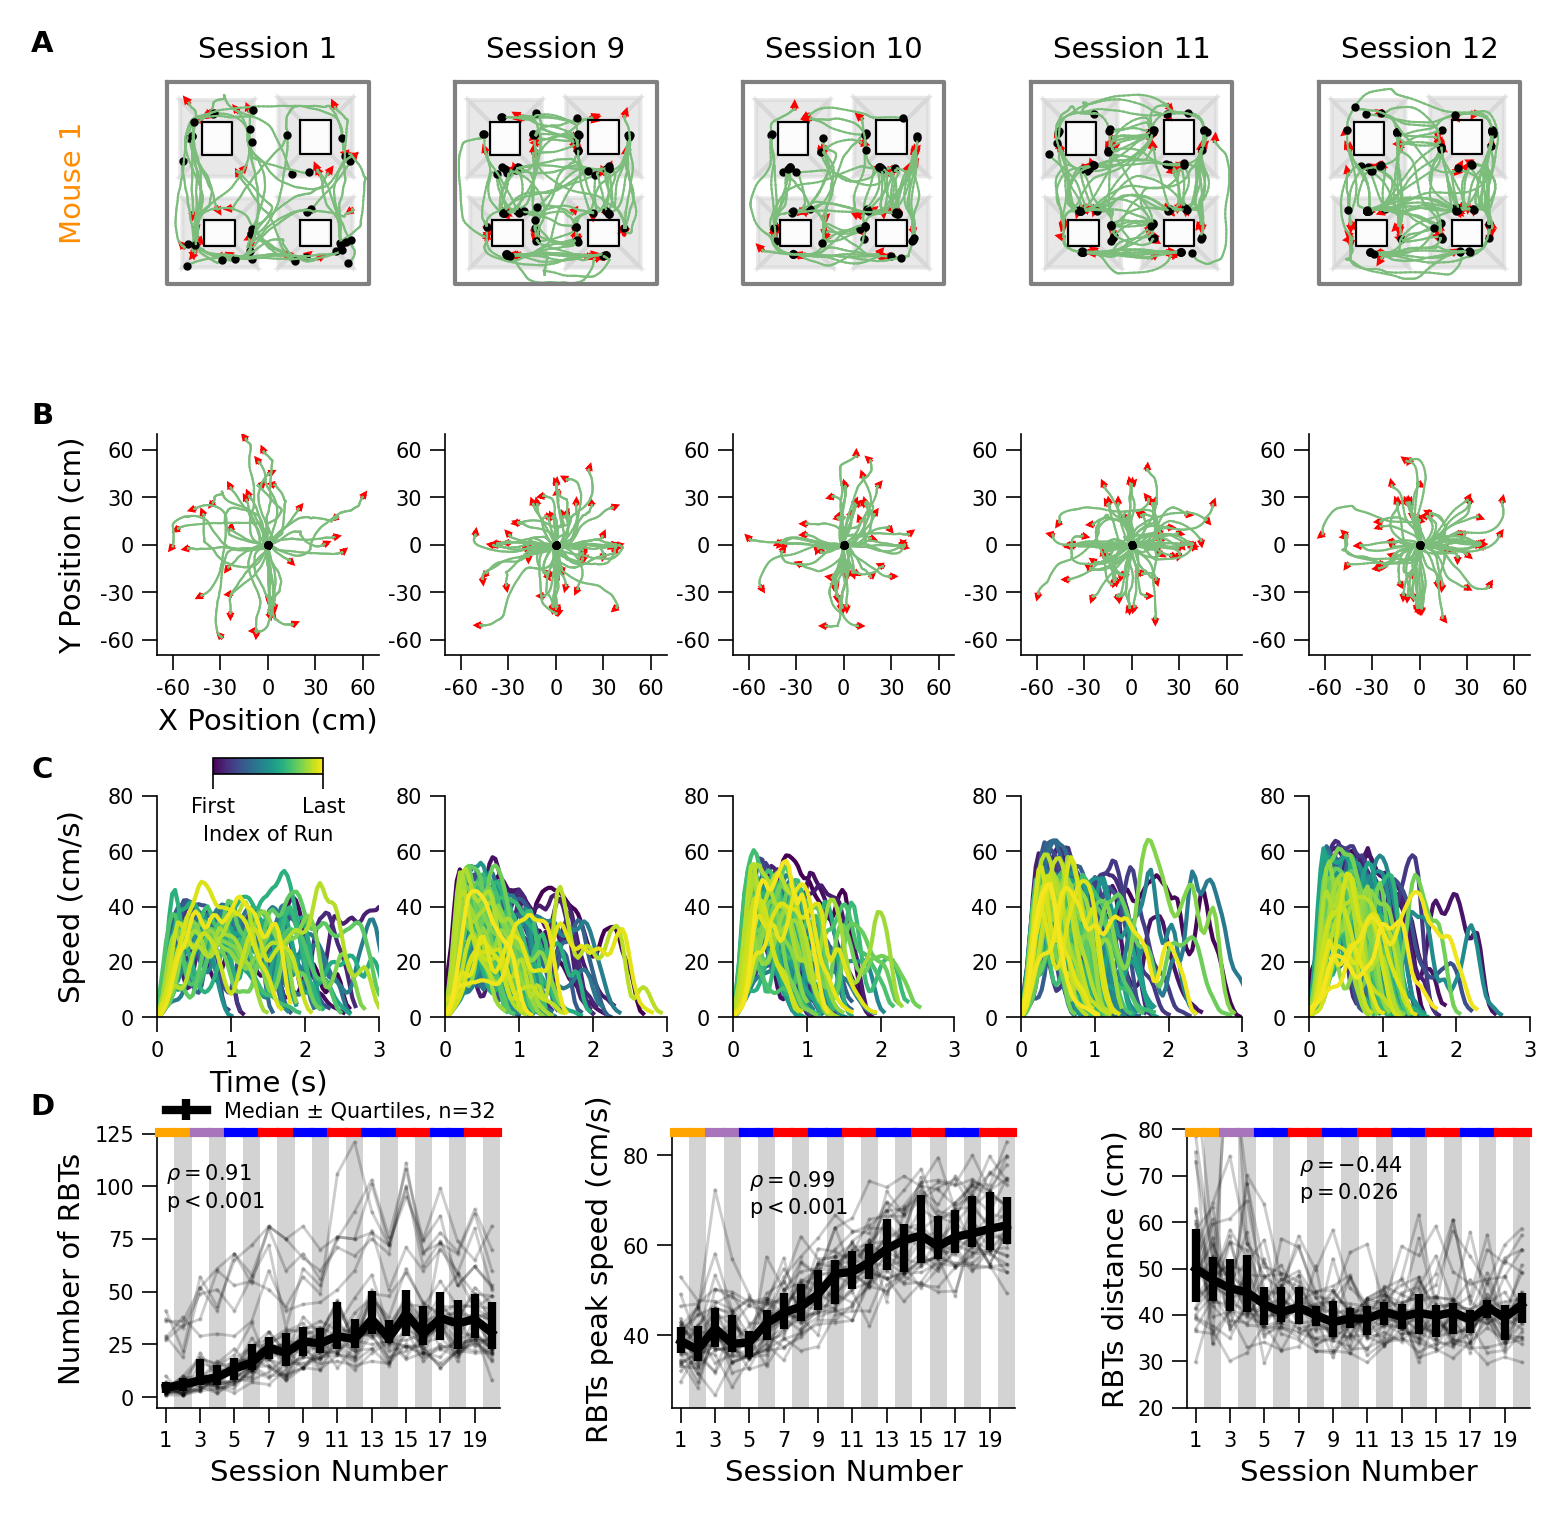

In [ ]:
from IPython.display import display
from PIL import Image

# Load and display the image
img = Image.open("FigureS10.png")
display(img)

# 1. Imports necessary libraries and functions

In [2]:
import os
from processing_TowerCoordinates import *
from processing_session_trajectory import *
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pickle
import scipy.ndimage as ndimage
import warnings 
from scipy.stats import spearmanr
from bisect import bisect
from matplotlib.colors import LinearSegmentedColormap

plt.style.use('paper.mplstyle')



In [3]:
plotintermediatesteps = False

# 2. Select mice that will be analysed in the figure
### Define the data_folder where your MOU* folders are, enter the list of mice (MOU* folders), define the sessions that will be used for each animals

In [ ]:
# defining data folder path and mice list

# path_to_data_folder is the path of the folder where you store the folders of your different mice.

path_to_data_folder='/LocalData/ForagingMice/4TowersTaskMethodPaper_Data/Group2Data/'
# path_to_data_folder = '/Users/davidrobbe/Documents/Science/Data/ForagingMice/Group2Data/'
# path_to_data_folder='/home/david/MyLocalData/4TowersTask_MethodPaper/Group2Data'

# Analysing the entire group of mice
mice_to_analyse = ['MOU3974','MOU3975', 'MOU3987', 'MOU3988', 'MOU3991', 'MOU3992', 'MOU4551', 'MOU4552', 'MOU4560', 'MOU4561', 'MOU4562',
                   'MOU4563', 'MOU4623', 'MOU4964', 'MOU4965', 'MOU4986', 'MOU4987', 'MOU4988', 'MOU4993', 'MOU5007', 'MOU5008','MOU5130',
                   'MOU5131', 'MOU5136', 'MOU5140', 'MOU5142', 'MOU5143', 'MOU5144', 'MOU5145', 'MOU5148', 'MOU5149', 'MOU5158']

# Verify that all folders in mice_to_analyse are present in path_to_data_folder
missing_folders = [mouse for mouse in mice_to_analyse if not os.path.isdir(os.path.join(path_to_data_folder, mouse))]

if missing_folders:
    print("Missing mice folders:", missing_folders)
else:
    print("All mice folders are present in data folder.")

# Print the number of mice, the list of mice
print(f' {len(mice_to_analyse)} {"mice" if len(mice_to_analyse) > 1 else "mouse"} will be analysed\n')

# Select the number of sessions that will be analysed for each mice knowing the analysis starts with the first session (familiarisation)
first_and_last_session_indexes = [0,20]
# Select the number of sessions that will be in statistics
first_and_last_session_indexes_stats = [1,20]
# Setting the seed for random processes used in statistics
seed = 27
np.random.seed(seed)
# Select the offset to apply to the number of the sessions when plotting. By default, it is equal to the number of the first session.
# It resulsts in sessions being named respectively to their actual positions in the data set. TODO: Should reformulate this 
session_index_offset = first_and_last_session_indexes[0]


All mice folders are present in data folder.
 32 mice will be analysed



In [5]:
# Chose mice that will highlighted in statistics
illustration_mice = ['MOU3974', 'MOU4561']

# Chose the color with which the illustration mice will highlighted with
illustration_colors = ['darkorange', 'green']

# Set the limits of the x-axis on the statistics plots
xlim_stats = [first_and_last_session_indexes[0]+0.5,first_and_last_session_indexes[1]+0.5]


# 3. Select sessions to be analysed

In [6]:
# Mouse from which data will be used to generate the plot 
example_mouse_index = 0
example_mouse = illustration_mice[example_mouse_index]

# Chosing index of the sessions to show as examples. They are chosen by their index in the list of sessions selected with start_session_index and end_session_index
illustration_sessions_indexes = [0, 8, 9, 10, 11]

# Define the arena corners coordinates
arena_coordinates_cm = [[4.5, 88.86], [90.3, 88.86], [90.3, 2.7], [4.5, 2.7]]


# 4. General of functions

In [7]:
def force_aspect(ax, ratio=1):
    """
    Force the aspect ratio of the given axis (ax) to a specific ratio.
    The ratio parameter allows scaling of the aspect ratio. Default is 1.
    
    Arguments:
        ax (matplotlib.axes.Axes): Matplotlib axis object for plotting.
        ratio (float, optional): Ratio of the figure's dimensions
    
    """
    
    ratio = 1.0  # Set ratio to 1.0, making the aspect ratio 1:1 by default
    
    # Get the current limits of the x and y axes
    x_left, x_right = ax.get_xlim()  # Get the left and right x-axis limits
    y_low, y_high = ax.get_ylim()    # Get the lower and upper y-axis limits
    
    # Calculate the new aspect ratio and set it
    # The formula is the absolute ratio of the width and height, adjusted by the given ratio
    ax.set_aspect(abs((x_right - x_left) / (y_low - y_high)) * ratio)

def shuffled_spearman_test(mouse_values_persession, shuffle_number, hypothesis, illustration_mouse_name = None, first_and_last_session_indexes=[None,None]):
    
    """
    Compute the Spearman correlation coefficient of input session-wise data then compare it to a null distribution computed by shuffling
    the input data several times

    Arguments:
        mouse_values_persession (dict): Dictionary with session numbers as keys and the corresponding values as entries
        shuffle_number (int): Number of time the data will be shuffled and the corresponding correlation coefficient computed 
        hypothesis (string): Hypothesis tested, whether the values sequence is increasing or decreasing across sessions
        illustration_mouse_name (list, optional): List of mice from mouse_values_persession to use
        first_and_last_session_indexes (list, optional): List containing indexes of first and last session to plot
    
    Return:
        (list): list containing the Spearman correlation coefficient of the unshuffled data and the p-value associaed to the test
    """

    # Selecting mice to analyse
    if illustration_mouse_name is None:
        illustration_mouse_name = list(mouse_values_persession.keys())

    ### Compute the Spearman correlation coefficient distribution by shuffling data ###

    # Initialize the list where the Spearman correlation coefficients from shuffled data will be stored. 
    # This will be the null distribution of Spearman correlation coefficient
    spearman_rho_list = []
    
    # Shuffle the data shuffle_number times
    for _ in range(shuffle_number):

        # Initialize the list that will contain shuffled data
        shuffled_values_list = []
        
        # Iterate on every mice
        for mouse in illustration_mouse_name:

            # Checking if the current mouse has no value to plot
            if mouse not in mouse_values_persession:
                print(f"Mouse {mouse} not found in data. Skipping.")
                continue    

            # Selecting sessions under the limit
            sessions = copy.deepcopy(mouse_values_persession[mouse][first_and_last_session_indexes[0]:first_and_last_session_indexes[1]])

            # Extract sessions number
            session_indices = [session[0] for session in sessions]
            # Extract and shuffle values 
            shuffled_values = np.random.choice([session[1] for session in sessions], size=len(sessions), replace=False)
            # Store the shuffled values
            shuffled_values_list.append(shuffled_values)

        # Compute the median over all the mice
        median_values = np.nanmedian(shuffled_values_list,axis=0)
        # Compute the Spearman correlation coefficient of the median
        spearman_result = spearmanr(session_indices, median_values)
        # Store the coefficient
        spearman_rho_list.append(spearman_result[0])
    
    ### Compute the Spearman correlation coefficient of unshuffled data ###

    values_list = []

    for mouse in illustration_mouse_name:

        # Checking if the current mouse has no value to plot
        if mouse not in mouse_values_persession:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue    

        # Selecting sessions under the limit
        sessions = copy.deepcopy(mouse_values_persession[mouse][first_and_last_session_indexes[0]:first_and_last_session_indexes[1]])

        # Extract sessions number
        session_indices = [session[0] for session in sessions]

        # Extract values
        values = [session[1] for session in sessions]
        
        # Store the value
        values_list.append(values)

    # Compute the median over all the mice
    actual_median_values = np.nanmedian(values_list,axis=0)

    # Compute the Spearman correlation coefficient of the median
    actual_spearman_result = spearmanr(session_indices,actual_median_values, nan_policy='omit')
    actual_rho = actual_spearman_result[0]

    # Compute the p-value corresponding to the tested hypothesis
    if hypothesis=="increasing":
        # Computing the the proportion of the null distribution above the correlation coefficient of unshuffled data. This is the p-value
        p_value = len(spearman_rho_list[bisect(np.sort(spearman_rho_list), actual_rho):])/len(spearman_rho_list)
    elif hypothesis=="decreasing":
        # Computing the the proportion of the null distribution below the correlation coefficient of unshuffled data. This is the p-value
        p_value = len(spearman_rho_list[:bisect(np.sort(spearman_rho_list), actual_rho)])/len(spearman_rho_list)
    else:
        # Raise an error if no valid hypothesis was made
        print("ERROR : Invalid hypothesis. Please specify increasing or decreasing")
        return

    return actual_rho, p_value

def plot_shuffled_spearman_test_res(ax, text_loc, mouse_values_persession, n_shuffles, hypothesis, color='black', illustration_mouse_name=None, first_and_last_session_indexes=[1,None]):

    """
    Plots the result of shuffled_spearman_test as a text on a figure.

    Arguments:
        ax (matplotlib.axes.Axes): Axes object for plotting
        text_loc (list): coordinate of the text (in data units)
        mouse_values_persession (dict): Dictionary with session numbers as keys and the corresponding values as entries
        shuffle_number (int): Number of time the data will be shuffled and the corresponding correlation coefficient computed 
        hypothesis (string): Hypothesis tested, whether the values sequence is increasing or decreasing across sessions
        color (str): Color of the text
        illustration_mouse_name (list, optional): List of mice from mouse_values_persession to use
        first_and_last_session_indexes (list, optional): List containing indexes of first and last session to plot
    
    """

    test_res = shuffled_spearman_test(mouse_values_persession, n_shuffles, hypothesis, illustration_mouse_name=illustration_mouse_name, first_and_last_session_indexes=first_and_last_session_indexes)    

    if test_res[1]==0:
        
        ax.text(text_loc[0],text_loc[1],rf'$\rho = {round(test_res[0],2)}$' + '\n' + rf'p$ < 0.001$', fontsize=5, color=color) 

    else:

        ax.text(text_loc[0],text_loc[1],rf'$\rho = {round(test_res[0],2)}$' + '\n' + rf'p$ = {round(test_res[1],3)}$', fontsize=5, color=color)

In [8]:
def cm2inch(value):

    """
    Converts centimeters to inches for figure size.

    Arguments:
        value (float): value to convert in cm 

    Returns:
        float: value converted in inches

    """

    return value/2.54

# 5. Panel A

In [9]:
# Setting the path to the example mouse's data folder
folder_path_example_mouse_to_analyse=os.path.join(path_to_data_folder,example_mouse)


In [10]:
def plot_run_between_towers(folder_path_mouse_to_analyse, session_index, arena_coordinates, ax, q=4, time_start=None, time_end=None, start_session_index=0):
    
    """
    Plots trajectories of the selected run types.
    
    Arguments:
        folder_path_mouse_to_analyse (str): Path to the folder containing session data.
        session_index (int): Index of the session to analyse.
        arena_coordinates (list): List of four 2D coordinates, locating the corners of the arena.
        ax (matplotlib.axes.Axes): Matplotlib axis object for plotting.
        q (int, optional): Number of points used to determine movement direction to plot arrows. Default is 4.
        time_start (float, optional): Time of the at which the trajectory will start being displayed
        time_end (float, optional): Time of the at which the trajectory will stop being displayed
        start_session_index (int, optional): Index of the first session of the list, with respect to the total number of available sessions.
                                             This should be the same value as the global variable start_session_index.
        
    """
    
    # Get all session folders that start with 'MOU' and sort them
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    session_to_analyse = sessions_to_analyse[start_session_index+session_index]

    # Define the output pickle filename and its full path
    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"        
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

    # Open and load the session data from the pickle file
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    # Extract the time data for the trajectory
    traject_time = session_data['timeofframes']

    # Set default start and end times if not provided
    if time_start is None:
        time_start = traject_time[0]
    if time_end is None:
        time_end = traject_time[-1]

    # Extract the smoothed X and Y positions of the mouse
    smoothed_positions = session_data['positions']
    smoothed_Xpositions = smoothed_positions[0]
    smoothed_Ypositions = smoothed_positions[1]

    # Extract epoch data and trapeze coordinates
    all_epochs = session_data['all_epochs']
    all_trapezes_coordinates_cm = session_data['all_trapezes_coordinates_cm']
    
    # Retrieve the epochs corresponding to the provided runtype
    run_between_towers = all_epochs.get('run_between_towers')
    
    # Plot each square and trapeze using the same color for each tower
    fill_colors = ['lightgray'] * 4  # Use a list of light blue colors for trapezes
    
    for i, (tower, trapezes) in enumerate(all_trapezes_coordinates_cm.items()):
        for j, (trapeze, coordinates) in enumerate(trapezes.items()):
            # Close the trapeze polygon by appending the first vertex
            coordinates_copy = coordinates + [coordinates[0]]
            x_coords, y_coords = zip(*coordinates_copy)
            
            # Fill the trapeze area with the color
            ax.fill(x_coords, y_coords, color=fill_colors[j % len(fill_colors)], alpha=0.5)

    # Loop through each epoch in the runtype and plot the trajectory
    for run_between_towers in run_between_towers:
        # Get the start and end indices of the current epoch
        start_index, end_index = run_between_towers[0][0], run_between_towers[0][1]

        # Skip the epoch if it is outside the time window
        if traject_time[start_index] < time_start or traject_time[end_index] > time_end:
            continue
        
        # Check that the start and end indices are within the bounds of the trajectory time array
        if start_index < 0 or end_index >= len(traject_time):
            print(f"Indexes out of bounds")
            continue

        # Extract the positions for the current epoch
        runtype_epoch_Xpositions = smoothed_Xpositions[start_index:end_index + 1]
        runtype_epoch_Ypositions = smoothed_Ypositions[start_index:end_index + 1]
        
        numberofpositions = len(runtype_epoch_Xpositions)

        # Ensure that the lengths of X and Y positions match
        if len(runtype_epoch_Xpositions) != len(runtype_epoch_Ypositions):
            raise ValueError("The lengths of X and Y positions lists must be the same.")
        
        # Define color of trajectory
        color = '#7CBD7C'
        
        # Loop through the positions to plot the trajectory
        for index in range(numberofpositions - 2):
            # Plot the line segment between consecutive positions
            ax.plot(runtype_epoch_Xpositions[index:index + 2], runtype_epoch_Ypositions[index:index + 2], color=color, linewidth=0.5)
                
        # Plot the start point as a small black circle
        ax.plot(runtype_epoch_Xpositions[0], runtype_epoch_Ypositions[0], color='black', marker='o', markersize=1)

        # Compute the direction of the arrow using the last 'q' positions (default is 4)
        if len(runtype_epoch_Xpositions) >= q:
            dx = runtype_epoch_Xpositions[-1] - runtype_epoch_Xpositions[-q]
            dy = runtype_epoch_Ypositions[-1] - runtype_epoch_Ypositions[-q]
            
            # Normalize the direction vector
            norm = np.hypot(dx, dy)
            if norm != 0:
                dx /= norm
                dy /= norm
            
            # Plot the direction arrow at the end point
            ax.arrow(runtype_epoch_Xpositions[-1], runtype_epoch_Ypositions[-1], dx, dy,
                      head_width=1, head_length=1, fc='red', ec='red')
        
    tower_coordinates = session_data['towers_coordinates_cm']

    # Plot each tower
    for i, (tower_name, vertices) in enumerate(tower_coordinates.items()):
        tower_x, tower_y = zip(*vertices + [vertices[0]])
        ax.fill(tower_x, tower_y, 'black', alpha=0.01)
        ax.plot(tower_x, tower_y, 'k-', linewidth=0.5)
            
    # Draw the arena perimeter
    arena_x, arena_y = zip(*arena_coordinates + [arena_coordinates[0]])
    ax.plot(arena_x, arena_y, 'grey', linewidth=1)
    
    # Hide the spines (axes) from the plot
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Remove the ticks from the x and y axes
    ax.set_xticks([])
    ax.set_yticks([])


In [11]:
if plotintermediatesteps:
    fig = plt.figure(figsize=(cm2inch(18), cm2inch(23)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)

    row1 = gs[0].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.1)

    ax_1 = []

    for j in range(len(illustration_sessions_indexes)):

        ax = plt.subplot(row1[j], aspect="equal")

        plot_run_between_towers(folder_path_example_mouse_to_analyse, illustration_sessions_indexes[j], arena_coordinates_cm, ax, q=4)

        ax.text(0.5, 1.1, f'Session {illustration_sessions_indexes[j]+1+session_index_offset}', va='center', ha='center', transform=ax.transAxes, fontsize=7)


# 6. Panel B

In [12]:
def plot_runs_between_towers_origin(folder_path_mouse_to_analyse, session_index, ax, start_session_index=0, q = 4, time_start = None, time_end = None, show_legend = True, xlim = None, ylim = None, show_xlabel = True, show_ylabel = True):
    """
    Plots the runs between towers with a fixed origin for a given session.

    Arguments:
        folder_path_mouse_to_analyse (str): Path to the folder containing session data.
        session_index (int): Index of the session to analyse.
        ax (matplotlib.axes.Axes): Matplotlib axis object for plotting.
        q (int, optional): Number of points to use for calculating the direction arrow (default is 4).
        time_start (float, optional): Start time for the plot (default is the first time point).
        time_end (float, optional): End time for the plot (default is the last time point).
        show_legend (bool, optional): Whether to show the legend (default is True).
        xlim (tuple, optional): X-axis limits for the plot.
        ylim (tuple, optional): Y-axis limits for the plot.
        show_xlabel (bool, optional): Whether to show the x-axis label (default is True).
        show_ylabel (bool, optional): Whether to show the y-axis label (default is True).
    """

    # Get all session folders that start with 'MOU' and sort them
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    session_to_analyse = sessions_to_analyse[start_session_index+session_index]

    # Construct the path to the output pickle file
    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

    # Load the session data from the pickle file
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    # Extract the time of frames from the session data
    traject_time = session_data['timeofframes']

    # Set default values for time_start and time_end if not provided
    if time_start is None:
        time_start = traject_time[0]
    if time_end is None:
        time_end = traject_time[-1]

    # Extract smoothed positions from the session data
    smoothed_positions = session_data['positions']
    smoothed_Xpositions = smoothed_positions[0]
    smoothed_Ypositions = smoothed_positions[1]

    # Copy the runs between towers data
    runs_around_tower = copy.deepcopy(session_data['all_epochs']['run_between_towers'])

    # Define a fixed origin point
    fixed_origin = (0, 0)

    # Plot each run around the tower
    for run_around_tower in runs_around_tower:
        start_index, end_index = run_around_tower[0][0], run_around_tower[0][1]

        # Skip runs that are outside the specified time range
        if traject_time[start_index] < time_start or traject_time[end_index] > time_end:
            continue

        # Extract the X and Y positions for the current run
        runtype_epoch_Xpositions = smoothed_Xpositions[start_index:end_index + 1]
        runtype_epoch_Ypositions = smoothed_Ypositions[start_index:end_index + 1]
        numberofpositions = len(runtype_epoch_Xpositions)

        # Translate the positions to the fixed origin
        start_x, start_y = runtype_epoch_Xpositions[0], runtype_epoch_Ypositions[0]
        translated_Xpositions = [x - start_x + fixed_origin[0] for x in runtype_epoch_Xpositions]
        translated_Ypositions = [y - start_y + fixed_origin[1] for y in runtype_epoch_Ypositions]

        # Define the color for the plot
        color = '#7CBD7C'

        # Plot the positions with lines connecting them
        for i in range(numberofpositions - 1):

            ax.plot(translated_Xpositions[i:i+2], translated_Ypositions[i:i+2], color=color, linewidth=0.5)

        # Plot the starting position with a marker
        ax.plot(translated_Xpositions[0], translated_Ypositions[0], marker='o', color='black', linewidth=0.5, markersize=1)

        # Plot an arrow indicating the direction of the last segment
        if len(translated_Xpositions) >= q:
            dx = translated_Xpositions[-1] - translated_Xpositions[-q]
            dy = translated_Ypositions[-1] - translated_Ypositions[-q]
            norm_speed = np.hypot(dx, dy)
            if norm_speed != 0:
                dx /= norm_speed
                dy /= norm_speed
            ax.arrow(translated_Xpositions[-1], translated_Ypositions[-1], dx, dy,
                     head_width=1, head_length=1, fc='red', ec='red')

    # Set the x-axis label if show_xlabel is True
    if show_xlabel:
        ax.set_xlabel('X Position (cm)')

    # Set the y-axis label if show_ylabel is True
    if show_ylabel:
        ax.set_ylabel('Y Position (cm)')

    # Set the x and y axis limits
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Hide the right and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # Show the legend if show_legend is True
    if show_legend:
        ax.legend(loc=[0.4, 1.2], frameon=False)


In [13]:
if plotintermediatesteps:
    fig = plt.figure(figsize=(cm2inch(18), cm2inch(23)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.5)

    row2 = gs[0].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.1)

    # Iterate on illustrative sessions
    for k in range(len(illustration_sessions_indexes)):

        ax = plt.subplot(row2[k], aspect="equal")

        # Plot the realigned run between towers of the illustrative sessions
        plot_runs_between_towers_origin(folder_path_example_mouse_to_analyse, illustration_sessions_indexes[k], ax, q=4, show_xlabel= True if k==0 else False, show_ylabel= True if k==0 else False, show_legend= False, xlim=(-70,70), ylim=(-70,70))
        # Set the x and y ticks
        ax.set_xticks([-60,-40,-20, 0, 20, 40, 60])
        ax.set_yticks([-60,-40,-20, 0, 20, 40, 60])

    plt.show()

# 7. Panel C

In [14]:
def plot_runs_between_speed_profiles(folder_path_mouse_to_analyse, session_index, ax, time_start = None, time_end = None, start_session_index = 0, xlim = None, ylim = None, show_xlabel = True, show_ylabel = True, show_color_bar = True, colorbar_position=[0.25, 0.8, 0.5, 0.07]):
    """
    Plots the speed profiles of runs between towers for a given session.

    Arguments:
        folder_path_mouse_to_analyse (str): Path to the folder containing session data.
        session_index (int): Index of the session to analyse.
        ax (matplotlib.axes.Axes): Matplotlib axis object for plotting.
        time_start (float, optional): Start time for the plot (default is the first time point).
        time_end (float, optional): End time for the plot (default is the last time point).
        start_session_index (int, optional): Index of the first session of the list, with respect to the total number of available sessions.
                                             This should be the same value as the global variable start_session_index.
        xlim (tuple, optional): X-axis limits for the plot.
        ylim (tuple, optional): Y-axis limits for the plot.
        show_xlabel (bool, optional): Whether to show the x-axis label (default is True).
        show_ylabel (bool, optional): Whether to show the y-axis label (default is True).
        show_color_bar (bool, optional): Whether to show the color bar (default is True).
    """

    # Get all session folders that start with 'MOU' and sort them
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    session_to_analyse = sessions_to_analyse[start_session_index+session_index]

    # Construct the path to the output pickle file
    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

    # Load the session data from the pickle file
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    # Extract the time of frames from the session data
    traject_time = session_data['timeofframes']

    # Set default values for time_start and time_end if not provided
    if time_start is None:
        time_start = traject_time[0]
    if time_end is None:
        time_end = traject_time[-1]

    # Extract speeds from the session data
    speeds = session_data['speeds']

    # Copy the runs between towers data
    runs_between_towers = copy.deepcopy(session_data['all_epochs']['run_between_towers'])

    # Initialize the total number of runs
    n_total = 0

    # Count the number of valid runs within the specified time range
    for run_between_towers in runs_between_towers:
        start_index, end_index = run_between_towers[0][0], run_between_towers[0][1]
        if traject_time[start_index] < time_start or traject_time[end_index] > time_end:
            continue
        n_total += 1

    # Define the colormap and normalization for the color bar
    cmap = plt.cm.viridis
    norm = Normalize(vmin=0, vmax=n_total)

    # Initialize the local index for color mapping
    local_index = 0

    # Plot each run between towers
    for run_between_towers in runs_between_towers:
        start_index, end_index = run_between_towers[0][0], run_between_towers[0][1]
        if traject_time[start_index] < time_start or traject_time[end_index] > time_end:
            continue

        # Adjust the time for the current run
        adjusted_time = [t - traject_time[start_index] for t in traject_time[start_index:end_index + 1]]

        # Plot the speed profile for the current run
        ax.plot(adjusted_time, speeds[start_index:end_index + 1], color=cmap(norm(local_index)))
        local_index += 1

    # Set the x-axis label if show_xlabel is True
    if show_xlabel:
        ax.set_xlabel('Time (s)')

    # Set the y-axis label if show_ylabel is True
    if show_ylabel:
        ax.set_ylabel('Speed (cm/s)')

    # Set the x and y axis limits
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Show the color bar if show_color_bar is True
    if show_color_bar:
        cbax = ax.inset_axes(colorbar_position)
        cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), cax=cbax, orientation='horizontal')
        cbar.set_label('Index of Run', fontsize=5)
        cbar.set_ticks([0, n_total])
        cbar.set_ticklabels(['First', 'Last'], fontsize=5)


In [15]:
if plotintermediatesteps:
    fig = plt.figure(figsize=(cm2inch(18), cm2inch(23)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)

    row3 = gs[0].subgridspec(1, 5, wspace=.5, hspace=.1)

    # Iterate on illustrative sessions
    for l in range(len(illustration_sessions_indexes)):

        ax = plt.subplot(row3[l], aspect="equal")

        # Plot the speed time profiles of the illustrative sessions
        plot_runs_between_speed_profiles(folder_path_example_mouse_to_analyse, illustration_sessions_indexes[l], ax, xlim=(0,3), ylim=(0,80), show_xlabel= True if l==0 else False, show_ylabel= True if l==0 else False, show_color_bar= True if l==0 else False, colorbar_position=[0.25, 1.1, 0.5, 0.07])
        # Set the plot shape to square
        force_aspect(ax,ratio=1)

    plt.show()

# 8. Panel D

In [16]:
def finding_mouse_rewarded_direction(folder_path_mouse_to_process, session_index, start_session_index=0):
    
    """
    Determines the rewarded direction for the last session of a given mouse.
    In the protocol this notebook is used for, the rewarded direction of the 
    last session is the same as in all the sessions where rewarding is allowed. 
    
    Arguments:
        folder_path_mouse_to_process (str): Path to the folder containing mouse sessions folders.
        session_index (int): Index of the session that will be used to define the rewarded direction
        start_session_index (int, optional): index of the first session in the list of sessions to analyse. 
                                   If different from 0, the session index should refer to 
                                   the index of the session in the sub-list of session to process, not the total list 

    Returns:
        str: 'CW' (Clockwise) if the rewarded direction is 270 degrees,
             'CCW' (Counterclockwise) if the rewarded direction is 90 degrees,
             numpy.nan if reward delivery is not allowed 
             None if an error occurs.
    """
    
    # Get all session folders that start with 'MOU' and sort them
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    sessions_to_process = sessions_to_process[start_session_index:]

    # Load data from the last session
    session_traj_df, session_turns_df, session_param_df = load_data(folder_path_mouse_to_process, sessions_to_process[start_session_index+session_index])

    # Extract rewarded direction in degrees
    rewarded_direction_degrees = session_param_df["potentialRewardedDirections"][0]

    # Check if reward delivery is allowed
    if session_param_df["allowRewardDelivery"][0]:

        # Determine the rewarded direction based on the extracted value
        if rewarded_direction_degrees == '[270]':
            rewarded_direction = 'CW'  # Clockwise

        elif rewarded_direction_degrees == '[90]':
            rewarded_direction = 'CCW'  # Counterclockwise
            
        elif rewarded_direction_degrees == '[90, 270]':
            rewarded_direction = 'both'  # Both directions

        else:
            print('ERROR: Unexpected unique rewarded direction value:', rewarded_direction_degrees)
            return None  # Explicitly return None to indicate failure
    
    else:

        # Rewarded direction is set to X if reward delivery os not allowed
        rewarded_direction = 'X'

    return rewarded_direction

In [17]:
def plot_learning_curve_alt_direction(mouse_metric_persession, ax, mice_list=None, start_session_index=0, mice_to_highlight=[], mice_to_highlight_labels=[None,None], show_individual_mice=True,
                         median_color='black', show_xlabel=True, ylabel='', main_line_label=None, 
                         tick_interval=1, index_offset=0, xlim=[None,None], ylim=None, show_background_legend=False, show_legend=True):
    """
    Plots a given metric across sessions for multiple mice (also called a learning curves). Each session is color coded differently depending on
    it rewarding regime, and whether it happened it the morning or afternoon.

    Arguments:
        mouse_metric_persession (dict): Dictionary where keys are mouse IDs and values are lists of (session_index, value) lists.
        ax (matplotlib.axes.Axes): Axes object for plotting.
        mice_list (list, optional): List of mice to include in the plot. Defaults to all mice in the mouse_metric_persession.
        start_session_index (int, optional): index of the first session in the list of sessions to analyse. 
                                   If different from 0, the session index should refer to 
                                   the index of the session in the sub-list of session to process, not the total list
        mice_to_highlight (list, optional): List of up to two mice IDs to highlight with distinct colors.
        mice_to_highlight_labels (list, optional): List of the label of the mice to highlight.
        show_individual_mice (bool, optional): If true, plot a line for each individual mouse.
        session_limit (tuple, optional): Inrerval of session indexes to plot. Defaults to [None,None] (plot all sessions).
        show_xlabel (bool, optional): Whether to display the x-axis label. Defaults to True.
        ylabel (str, optional): Label for the y-axis.
        main_line_label (str, optional): Label of the median and quartiles range.
        tick_interval (int, optional): Interval for x-axis tick marks. Defaults to 1.
        index_offset (int, optional): Offset to apply to the numbers in the x axis. Use it if you want to the first sessions to be named '1'.
        xlim (tuple, optional): Tuple specifying x-axis limits. Defaults to None.
        ylim (tuple, optional): Tuple specifying y-axis limits. Defaults to None.
        show_background_legend (bool, optional): Whether to show the legend of the session color codes. Defaults to False.
        show_legend (bool, optional): Whether to show the legend. Defaults to True.
    """

    # If no mice are specified, use all available mice
    if mice_list is None:
        mice_list = list(mouse_metric_persession.keys())

    all_session_indexes = set()  # Track all session indices across selected mice
    values_per_session = {}  # Store values for each session across mice

    # Loop through each mouse and gather session data
    for mouse in mice_list:
        if mouse not in mouse_metric_persession:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue    

        # Selecting the sub-list of sessions to analyse
        sessions = mouse_metric_persession[mouse]

        # Extract session indices and corresponding values
        session_indexes = [session[0] for session in sessions]
        values = [session[1] for session in sessions]

        # Plot learning curves for each mouse if show_individual_mice is True
        if show_individual_mice:
    
            if mouse in mice_to_highlight: # Plot the values in opac dark orange or green if the current mouse is in mice_to_highlight
                highlight_colors = ["darkorange", "green"]
                color_idx = mice_to_highlight.index(mouse) if mice_to_highlight.index(mouse) < len(highlight_colors) else 0
                ax.plot(session_indexes, values, color=highlight_colors[color_idx], marker='o', linewidth=0.7, 
                        markersize=1, label=mice_to_highlight_labels[mice_to_highlight.index(mouse)], zorder=100*len(median_color))
            else:
                ax.plot(session_indexes, values, marker='o', linewidth=0.7, markersize=1, alpha=0.2, markeredgewidth=0.0, color=median_color)

        # Update session index tracking
        all_session_indexes.update(session_indexes)
        for session, value in sessions:
            if session not in values_per_session:
                values_per_session[session] = []
            values_per_session[session].append(value)

    # Convert session indices to a sorted list
    sorted_sessions = sorted(all_session_indexes)

    # Compute median and 25th-75th percentile range for each session
    median_values = []
    lower_quartile = []
    upper_quartile = []

    for session in sorted_sessions:
        session_values = values_per_session[session]
        median_values.append(np.nanmedian(session_values))
        lower_quartile.append(np.nanpercentile(session_values, 25))
        upper_quartile.append(np.nanpercentile(session_values, 75))

    median_values = np.array(median_values)
    lower_quartile = np.array(lower_quartile)
    upper_quartile = np.array(upper_quartile)

    # Find the first mouse of the sample. It will be used to determine the rewarded direction of the session
    folder_path_first_mouse = os.path.join(path_to_data_folder,list(mouse_metric_persession.keys())[0])

    # Initialize a set to contain colors that have already been shown in the legend
    used_colors = set([])

    # Iterate on the index of sessions
    for session_index in range(len(sorted_sessions)):
            
            # Fint the rewarded direction of the session
            rewarded_direction = finding_mouse_rewarded_direction(folder_path_first_mouse, session_index, start_session_index)

            # Checks if rewarding was available
            rewarding = rewarded_direction != 'X'

            # If there is no rewarding, color code the session in orange
            if not(rewarding):
                band_color = "orange"
                direction_label = "Familiarization" if show_background_legend else None

            # If both directions are rewarded, color code the session in purple
            elif rewarded_direction == "both":
                band_color = "#a875bc"
                direction_label = "Both rewarded directions" if show_background_legend else None

            # If the day is odd, color code the sessions in this day in blue
            elif session_index%4 < 2:
                band_color = "blue"
                direction_label = "CW rewarded direction" if show_background_legend else None

            # Else, color code them in red
            else:
                band_color = "red"
                direction_label = "CCW rewarded direction" if show_background_legend else None

            ax.axvspan(session_index+1 - 0.49, session_index+1 + 0.49, ymin=0.979, ymax=0.998,
                       color=band_color, zorder=3, clip_on=False, label = direction_label if not(band_color in used_colors) else None )

            # Add the color code to the used_colors set so that it will not appear several times on the legend
            used_colors.add(band_color)

            # Color the session in clear grey if it happened in afternoon, and light grey if it happened on morning
            if session_index % 2 != 0:  # Odd (PM sessions)
                
                vspan_color = "lightgrey"
                vspan_label = "Afternoon" if show_background_legend else None

                ax.axvspan(
                    session_index + 0.5, session_index + 1.5,
                    color="lightgrey", zorder=0, label = vspan_label if not(vspan_color in used_colors) else None,
                    lw=0
                )
                
            else:
                
                vspan_color = "white"
                vspan_label = "Morning" if show_background_legend else None

                ax.axvspan(
                    session_index + 0.5, session_index + 1.5,
                    color=vspan_color, zorder=0, label = vspan_label if not(vspan_color in used_colors) else None,
                    lw=0
                )

            used_colors.add(vspan_color)


    # If the median and quartiles range don't have a label, give them a default label.
    if not main_line_label:

        main_line_label = f'Median \u00B1 Quartiles, n={len(mice_list)}'

    # Plot median learning curve with shaded 25th-75th percentile range
    ax.errorbar(np.array(sorted_sessions)+index_offset, median_values, yerr=[median_values-lower_quartile, upper_quartile-median_values], alpha=1, color=median_color, linewidth = 2, label=main_line_label, zorder=50*len(median_color))

    # Set axis labels and formatting
    if show_xlabel:
        ax.set_xlabel('Session Number', fontsize=7)
    
    ax.set_ylabel(ylabel, fontsize=7)

    # Ensure x-axis labels are integers
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    # Set x-ticks at specified intervals
    if all_session_indexes:
        max_index = max(all_session_indexes)
        ax.set_xticks(range(1, max_index + 1, tick_interval))

    # Apply x and y axis limits if provided
    if xlim is not None:
        ax.set_xlim(xlim)
    
    if ylim is not None:
        ax.set_ylim(ylim)

    # Show legend if required
    if show_legend:

        if show_background_legend:
            # Organising background legend so that the Morning/Afternoon are shown first
            handles, labels = plt.gca().get_legend_handles_labels()
            current_order = list(range(len(handles)))
            target_order = current_order[1:3] + [current_order[0]] + current_order[3:]
            ax.legend([handles[idx] for idx in target_order],[labels[idx] for idx in target_order], frameon=False, loc=(0,1.05), ncol=2)

        else:
            ax.legend(frameon=False, loc=(0,1), ncol=2)



### This cell computes and store metrics that will be plotted for each mouse across sessions. Those metrics are:
- The number of runs between towers
- The median of runs between towers maximum speed

In [18]:
# Initialize dictionaries to store the various metrics for each mouse
mouse_maximum_run_speed_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_median_run_distance_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_total_runs_persession = {mouse: [] for mouse in mice_to_analyse}

# Iterate through each mouse to process its data
for mouse in mice_to_analyse:

    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)
    
    # Get the list of sessions for the current mouse
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])
    
    sessions_to_process = sessions_to_process[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    nb_sessions = len(sessions_to_process)
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    print(sessions_to_process, '\n')

    # Process each session for the current mouse
    for sessionindex,session_to_process in enumerate(sessions_to_process):

        # Determine the rewarded direction for all sessions of the current mouse
        session_traj_df, session_runs_df, session_param_df=load_data(folder_path_mouse_to_process,session_to_process)

        # Define the pickle file path
        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)
        
        # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exists for session {session_to_process}, skipping .....')
            continue  # Skip to the next session if the pickle file does not exist

        # Load the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Extract run between towers results from the session data
        runs_between_towers = session_data['all_epochs']['run_between_towers']

        # Compute the total number of runs between towers
        TotalRuns = len(runs_between_towers)        
        
        # Initialize lists to store runs speeds
        runs_max_speed = []
        runs_distance = []

        # Iterate through each run between towers
        for n in range(TotalRuns):   
            run = runs_between_towers[n]
            
            # Append metric in the list
            runs_max_speed.append(run[3]["maxspeed"])
            runs_distance.append(run[3]["distance"])

        # Append session data to the respective dictionaries
        mouse_maximum_run_speed_persession[mouse].append([sessionindex+1,np.median(runs_max_speed)])
        mouse_median_run_distance_persession[mouse].append([sessionindex+1,np.median(runs_distance)])
        mouse_total_runs_persession[mouse].append([sessionindex+1,TotalRuns])


Mouse MOU3974. There is/are 20 sessions:
['MOU3974_20230304-1314', 'MOU3974_20230305-1535', 'MOU3974_20230306-1211', 'MOU3974_20230306-1752', 'MOU3974_20230307-1231', 'MOU3974_20230307-1742', 'MOU3974_20230308-1150', 'MOU3974_20230308-1714', 'MOU3974_20230309-1155', 'MOU3974_20230309-1705', 'MOU3974_20230310-1220', 'MOU3974_20230310-1702', 'MOU3974_20230311-1258', 'MOU3974_20230311-1801', 'MOU3974_20230312-1145', 'MOU3974_20230312-1648', 'MOU3974_20230313-1129', 'MOU3974_20230313-1725', 'MOU3974_20230314-1036', 'MOU3974_20230314-1620'] 

Mouse MOU3975. There is/are 20 sessions:
['MOU3975_20230304-1329', 'MOU3975_20230305-1550', 'MOU3975_20230306-1228', 'MOU3975_20230306-1810', 'MOU3975_20230307-1249', 'MOU3975_20230307-1800', 'MOU3975_20230308-1206', 'MOU3975_20230308-1731', 'MOU3975_20230309-1209', 'MOU3975_20230309-1720', 'MOU3975_20230310-1234', 'MOU3975_20230310-1716', 'MOU3975_20230311-1311', 'MOU3975_20230311-1814', 'MOU3975_20230312-1158', 'MOU3975_20230312-1702', 'MOU3975_20230

In [19]:
if plotintermediatesteps:
    fig = plt.figure(figsize=(cm2inch(18), cm2inch(6)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)

    row4 = gs[0].subgridspec(1, 3, wspace=.3, hspace=.3)
    ax_41 = plt.subplot(row4[0])
    ax_42 = plt.subplot(row4[1])
    ax_43 = plt.subplot(row4[2])

    # Plot the number of runs and median maximum speed of the runs between towers
    plot_learning_curve_alt_direction(mouse_total_runs_persession, ax=ax_41, xlim=xlim_stats, show_xlabel = True, ylabel='Number of runs', tick_interval=2, show_legend=True)
    plot_learning_curve_alt_direction(mouse_maximum_run_speed_persession, ax=ax_42, xlim=xlim_stats, show_xlabel = True, ylabel='Median of runs between towers \n maximum speed (cm/s)', tick_interval=2, show_legend=False)
    plot_learning_curve_alt_direction(mouse_median_run_distance_persession, ax=ax_43, xlim=xlim_stats, show_xlabel = True, ylabel='Median runs distance (cm)', tick_interval=2, show_legend=False)

    plt.show()

# 9. Whole figure 

/tmp/ipykernel_38148/2821363549.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


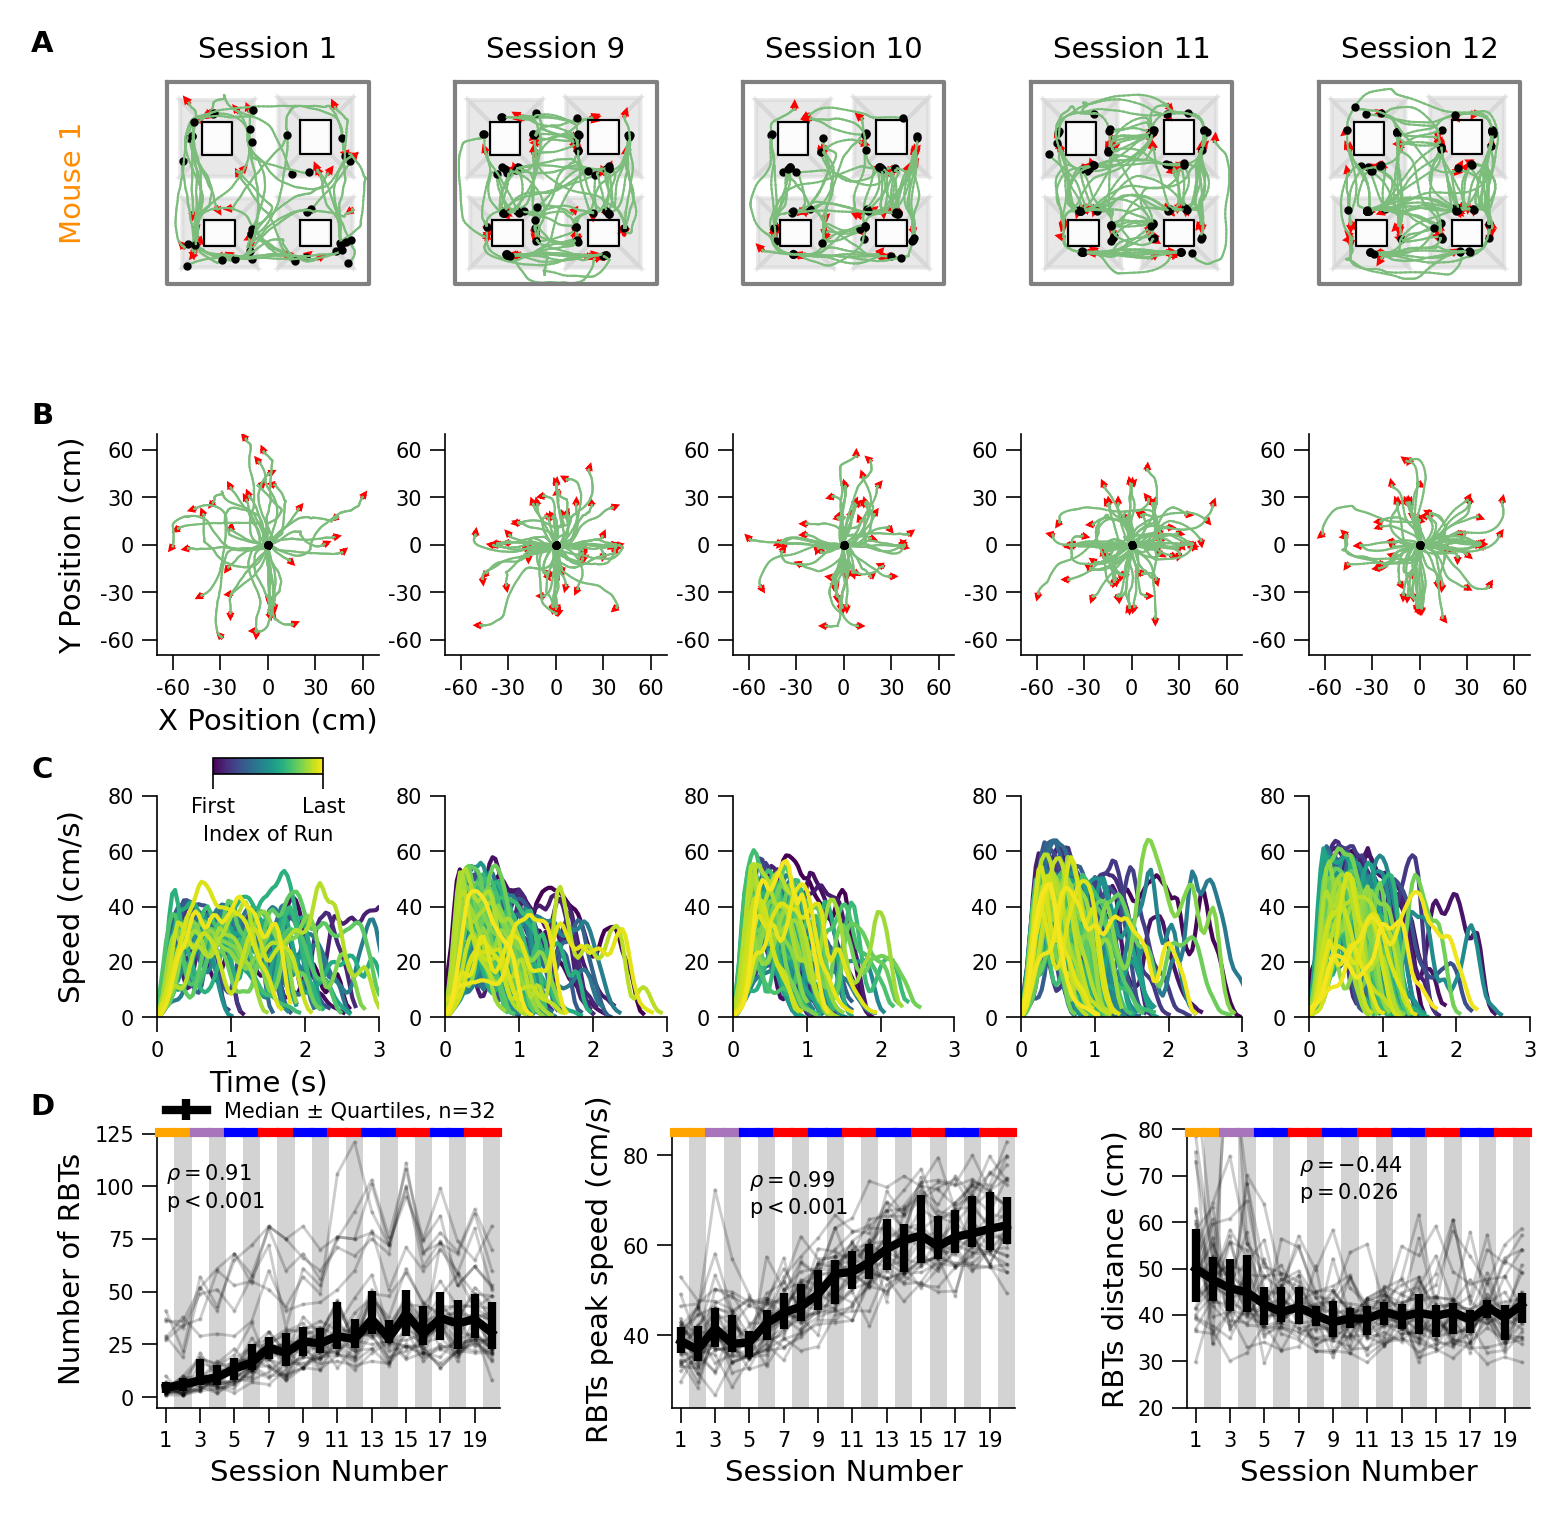

In [ ]:
fig = plt.figure(figsize=(cm2inch(15), cm2inch(15)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(4, 1 , hspace=0.3)

nb_illustration_sessions = len(illustration_sessions_indexes)

axes_to_align = []

### Panel A ###

row1 = gs[0].subgridspec(1, nb_illustration_sessions, wspace=.3)


for j in range(len(illustration_sessions_indexes)):

    ax = plt.subplot(row1[j], aspect="equal")

    if j==0:
        ax.text(-0.38, 0.5, f'Mouse {example_mouse_index+1}', color=illustration_colors[example_mouse_index],rotation=90, va='center', ha='center', transform=ax.transAxes, fontsize=7)

    plot_run_between_towers(folder_path_example_mouse_to_analyse, illustration_sessions_indexes[j], arena_coordinates_cm, ax, q=4)

    ax.text(0.5, 1.1, f'Session {illustration_sessions_indexes[j]+1+session_index_offset}', va='center', ha='center', transform=ax.transAxes, fontsize=7)

fig.text(.06, 0.88, 'A', weight='bold', va='center', ha='center', fontsize=7)

### Panel B ###

row2 = gs[1].subgridspec(1, nb_illustration_sessions, wspace=.3)

for k in range(len(illustration_sessions_indexes)):

    ax = plt.subplot(row2[k], aspect="equal")

    plot_runs_between_towers_origin(folder_path_example_mouse_to_analyse, illustration_sessions_indexes[k], ax, q=4, show_xlabel= True if k==0 else False, show_ylabel= True if k==0 else False, show_legend= False, xlim=(-70,70), ylim=(-70,70))
    ax.set_xticks([-60,-30, 0, 30, 60])
    ax.set_yticks([-60,-30, 0, 30, 60])

    if k==0:
        axes_to_align.append(ax)

fig.text(.06, 0.67, 'B', weight='bold', va='center', ha='center', fontsize=7)

### Panel C ###

row3 = gs[2].subgridspec(1, nb_illustration_sessions, wspace=.3)

# Iterate on illustrative sessions
for l in range(nb_illustration_sessions):

    ax = plt.subplot(row3[l], aspect="equal")

    # Plot the speed time profiles of the illustrative sessions
    plot_runs_between_speed_profiles(folder_path_example_mouse_to_analyse, illustration_sessions_indexes[l], ax, xlim=(0,3), ylim=(0,80), show_xlabel= True if l==0 else False, show_ylabel= True if l==0 else False, show_color_bar= True if l==0 else False, colorbar_position=[0.25, 1.1, 0.5, 0.07])
    # Set the plot shape to square
    force_aspect(ax,ratio=1)
    
    if l==0:
        axes_to_align.append(ax)

fig.text(.06, 0.47, 'C', weight='bold', va='center', ha='center', fontsize=7)

### Panel D ###

row4 = gs[3].subgridspec(1, 3, wspace=.5)
ax_41 = plt.subplot(row4[0])
ax_42 = plt.subplot(row4[1])
ax_43 = plt.subplot(row4[2])

plot_learning_curve_alt_direction(mouse_total_runs_persession, ax=ax_41, xlim=xlim_stats, show_xlabel = True, ylabel='Number of RBTs', tick_interval=2, show_legend=True)
plot_learning_curve_alt_direction(mouse_maximum_run_speed_persession, ax=ax_42, xlim=xlim_stats, show_xlabel = True, ylabel='RBTs peak speed (cm/s)', tick_interval=2, show_legend=False)
plot_learning_curve_alt_direction(mouse_median_run_distance_persession, ax=ax_43, xlim=xlim_stats,ylim=[20,80], show_xlabel = True, ylabel='RBTs distance (cm)', tick_interval=2, show_legend=False)

plot_shuffled_spearman_test_res(ax_41, (1,90), mouse_total_runs_persession, 1000,'increasing', first_and_last_session_indexes=first_and_last_session_indexes_stats)    

plot_shuffled_spearman_test_res(ax_42, (5,67), mouse_maximum_run_speed_persession, 1000,'increasing', first_and_last_session_indexes=first_and_last_session_indexes_stats)    

plot_shuffled_spearman_test_res(ax_43, (7,65), mouse_median_run_distance_persession, 1000,'decreasing', first_and_last_session_indexes=first_and_last_session_indexes_stats)    


fig.text(.06, 0.28, 'D', weight='bold', va='center', ha='center', fontsize=7)

axes_to_align.append(ax_41)

fig.align_ylabels(axes_to_align)

fig.tight_layout()
plt.savefig("FigureS10.png", facecolor='w', 
                edgecolor='none', bbox_inches='tight', format="png", dpi=300)

In [ ]:
# Save the figure as a PDF
fig.savefig("FigureS10.pdf", format="pdf", bbox_inches='tight', dpi=300)